# Required Functions

In [145]:
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.pyplot import pie,axis,show
%matplotlib inline

In [169]:
import pandas as pd
import json
import re
def load_dataframe(filename):
    with open(filename,'r') as f:
        df = pd.DataFrame(json.load(f))
        df['index'] = range(len(df))
        return df

def drop_cols(df,dropcols):
    return df[list(filter(lambda x:not re.search('|'.join(dropcols),x) ,df.columns))]

def plot_pie_chart(df,dropcols,dropre=['min','max','avg'],index=0):
    df = df.drop(dropcols,axis=1)
    df = drop_cols(df,dropre)
    dfi = df.loc[str(index),:]
    axis('equal')
    labels = [ '-'.join(list(map(str,item))) for item in list(dfi.items())]
    pie(dfi, labels=labels,startangle=0)
    show()
        
def plot_pie_charts(df,dropcols,dropre=['min','max','avg'],count=None):
    df = df.drop(dropcols,axis=1)
    df = drop_cols(df,dropre)
    count = len(df) if count is None else count
    for i in range(count):
        dfi = df.loc[str(i),:]
        axis('equal')
        labels = [ '-'.join(list(map(str,item))) for item in list(dfi.items())]
        pie(dfi, labels=labels,startangle=0)
        show()

def plot_pie_chart_(df,dropcols,dropre=['min','max','avg'],count=None,figdim=10):
    df = df.drop(dropcols,axis=1)
    df = drop_cols(df,dropre)
    count = len(df) if count is None else count
    rows = max(int(count/2),1)
    cols = 2 if count>1 else 1
    figsize = tuple([ figdim*rows for _ in range(rows) ])
    fig, ax = plt.subplots(rows,cols,figsize=figsize)
        
    for i in range(count):
        dfi = df.loc[str(i),:]
        ax = fig.add_subplot(rows,cols,(i%cols)+1)
        labels = [ '-'.join(list(map(str,item))) for item in list(dfi.items())]
        _, _ = ax.pie(dft.loc['0',:], startangle=0,labels=labels)
        ax.axis('equal')

def list_detections(output):
    dets_d = {}
    for ko in output.keys():
        d = output[ko]
        dets = []
        for k in d.keys():
            dc = d[k]
            dets.append(dc['output']['labels_detected'])
        dets_d[ko]=dets
    return dets_d

def count_elems(dct):
    count = {}
    sums = {}
    for k in dct.keys():
        count[k] = list(map(lambda l:len(l) ,dct[k]))
        sums[k] = sum(count[k])
    return count,sums

def read_dict(jsonfile):
    op = {}
    with open(jsonfile,'r') as f:
        op = json.load(f)
    return op

def get_intervals_data():
    its = list(map(read_dict,intervals_dicts))
    return its

def get_info_what_key(dct,key):
    for i in dct.keys():
        d = dct[i]
        for k in d.keys():
            if d[k]['key']==key:
                return k

def get_int_info(dct):
    res = {}
    for i in dct.keys():
        d = dct[i]
        res[i]={}
        for k in d.keys():
            key = d[k]['key']
            res[i][key]=[d[k]['info'],d[k]['success']]
            #res[i][key]['what']=k
    return res

def info_det(dct):
    res = {}
    for i in dct.keys():
        res[i] = dct[i]['detect']
    return res

def merge_intervals_info(detector_intervals):
    res = {}
    for d in dd.keys():
        k = dd[d]
        res[d]={'detect':k['detect'][0],'post_detection_ops':k['post_detection_ops'][0],'success':k['post_detection_ops'][1]}
    return res

def cpy_det_sucess_data(detector_intervals_merged,ints_dm):
    for k in ints_dm.keys():
        ints_dm[k][1] = detector_intervals_merged[k]['success']
    return ints_dm

# Fetch & Load Data

In [170]:
df_files = ['detection_model-time.json','extractor-time.json']
output_data_dict_file = 'output_data.json' 
intervals_dicts = ['ext-intervals_data.json','det-intervals_data.json']

In [171]:
drop_columns = True
drop_re=['min','max'] #drop all columns that have these words
dfs = list(map(load_dataframe,df_files))
if drop_columns:
    dfs = list(map(lambda d:drop_cols(d,drop_re),dfs))
data_dm,data_ex = dfs 
#dfex - DataFrame of extractor (main program)
#dfdm - DataFrame of Detector model
output_dict = read_dict(output_data_dict_file)

dts = list(map(get_int_info,get_intervals_data()))
ints_ex,ints_dm = list(map(info_det,dts)) #intervals data
detector_intervals_merged = merge_intervals_info(dts[1])
ints_dm = cpy_det_sucess_data(detector_intervals_merged,ints_dm)

detections_lst = list_detections(output_dict)
detections_count, detections_sum = count_elems(detections_lst)

#important takeaways:
#ints_dm and ints_ex, detections_count, data_dm,data_ex

# Inspect Data

In [172]:
print(data_ex.columns,'\n',data_dm.columns)

Index(['Total_time', 'download_video', 'detect-avg', 'name', 'input_file',
       'fetch_frame-total', 'load_video_file', 'load_model', 'detect-total',
       'init&prepare_model', 'save_annotations', 'fetch_frame-avg',
       'video_duration', 'video_file_size', 'index'],
      dtype='object') 
 Index(['detect-avg', 'name', 'post_detection_ops-total', 'input_file',
       'post_detection_ops-avg', 'load_model', 'import_deps', 'detect-total',
       'init_model', 'video_duration', 'video_file_size', 'index'],
      dtype='object')


## DataFrame from extractor (main program)

In [173]:
data_ex #DataFrame of extractor (main program)

,Total_time,download_video,detect-avg,name,input_file,fetch_frame-total,load_video_file,load_model,detect-total,init&prepare_model,save_annotations,fetch_frame-avg,video_duration,video_file_size,index
0,15.4602,1.8509,0.2782,yolo,Priceless Reactions to Ronaldo Goals The World...,1.8545,0.008,7.2599,3.8952,0.0962,0.3271,0.1325,281.633333,30.0,0


## DataFrame from Detector model

In [174]:
data_dm #DataFrame of Detector model

,detect-avg,name,post_detection_ops-total,input_file,post_detection_ops-avg,load_model,import_deps,detect-total,init_model,video_duration,video_file_size,index
0,0.0287,yolo,0.5751,Priceless Reactions to Ronaldo Goals The World...,0.0411,7.2516,0.0796,0.4016,0.0158,281.633333,30.0,0


# Plot Data

In [184]:
file_index = 0
file_index = str(file_index)
print('Plotting data for performance of',data_ex.loc[file_index]['name'].upper(),'on',data_ex.loc[file_index]['input_file'])

Plotting data for performance of YOLO on Priceless Reactions to Ronaldo Goals The World Will Never Forget!.mp4


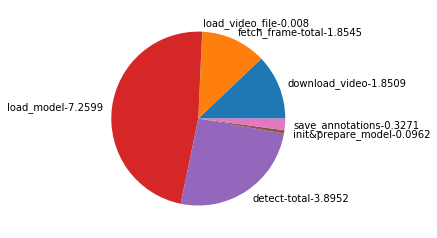

In [179]:
plot_pie_chart(data_ex,['name','index','input_file','Total_time','video_duration','video_file_size'],index=file_index)

In [191]:
#contour X(det count) vs time taken(multiple Y) for dm_detect and ex_detect
det_count = detections_count[file_index]
time_taken_per_frame_ex = ints_ex[file_index][0]
time_taken_per_frame_dm = ints_dm[file_index][0]
list(map(len,[det_count,time_taken_per_frame_ex,time_taken_per_frame_dm]))

[13, 14, 14]

In [ ]:
#running X (ith frame) , det count, time_dm,time_ex,

In [ ]:
#total det count vs time_det_total(ex,dm)

In [ ]:
# bar graph of detection time for dm with num dets

In [ ]:
#bar graph class vs det time

In [ ]:
#weightlift kinda thing for det time with successful detections and otherwise

In [ ]:
#pie chart

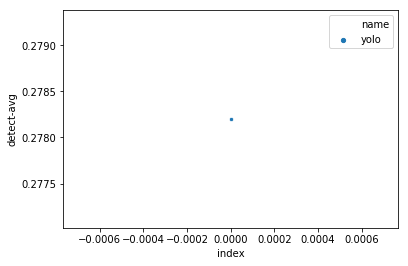

In [152]:
sns.scatterplot(data=data_ex,x='index',y='detect-avg',hue='name',size='name')

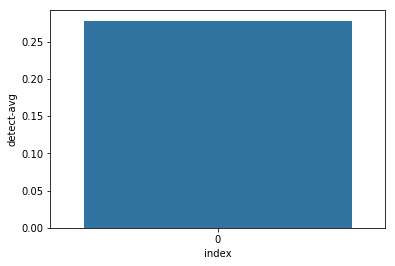

In [154]:
sns.barplot(x='index',y='detect-avg',data=data_ex)